In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 12,
    "axes.titlesize": 15,
    "axes.labelsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
})

n_folds = 5

In [32]:
variables = {
    "subharm_num": "Subharmonic cardinality",
    "subharm_per_second" : "Subharmonics per second",

    "subharm_sig_ratio": "Subharmonic-signal ratio",
    "density_num_slope" : "Number-density slope",
    "pct_subharm_num_2nd_half" : "Number-percentage in the second half", 
    "density_dur_slope": "Duration-density slope", 
    "pct_subharm_dur_2nd_half": "Duration-percentage in the second half",

    "first_occur": "First subharmonic occurence",
    "mean_inter_intervals": "Inter-subharmonic interval - mean", 
    "median_inter_intervals": "Inter-subharmonic interval - median",  
    "std_inter_intervals": "Inter-subharmonic interval - standard deviation",  
    "COV_inter_intervals": "Inter-subharmonic interval - CoV",
    
    "avg_dur": "Subharmonic duration - mean",
    "median_dur": "Subharmonic duration - median", 
    "std_dur": "Subharmonic duration - standard deviation", 
    "CV_dur": "Subharmonic duration - CoV", 
    "longest_dur": "Subharmonic duration - the longest",}

In [33]:
# features_overall_H_sorted = [
#     "avg_dur", # 38.51
#     "median_dur", # 37.39
#     "subharm_sig_ratio", # 34.43
#     "longest_dur", # 31.57
#     "std_dur", # 26.60
#     "subharm_per_second", # 24.81
#     "subharm_num", # 18.98
#     "std_inter_intervals",  # 15.02
#     "median_inter_intervals", # 13.64
#     "pct_subharm_num_2nd_half", # 10.85
#     "COV_inter_intervals", # 8.79
#     "mean_inter_intervals" # 8.10 
# ]

# df = pd.read_csv("overall_cont_speech_features.csv")
# # print(f"Original shape: {df.shape}")

# for col in features_overall_H_sorted:
#     df[col] = pd.to_numeric(df[col], errors="coerce")

# diagnoses = ["RBD", "PN", "MSA"]
# cms = []

# for diagnosis in diagnoses:

#     print(f"---------------HC vs. {diagnosis}---------------")
#     df_bin = df[df["group"].isin(["HC", diagnosis])].copy()

#     corr = df_bin[features_overall_H_sorted].corr().abs()
#     threshold = 0.8
#     selected = []

#     for f in features_overall_H_sorted:
#         if all(corr.loc[f, s] < threshold for s in selected):
#             selected.append(f)
#     print(f"Selected {len(selected)} features out of {len(features_overall_H_sorted)}")
#     print("Selected features:", selected)

#     df_bin = df_bin.dropna(subset=selected)
#     # print(f"Shape after corr and cleaning: {df_clean.shape}")

#     X = df_bin[selected]
#     y = (df_bin["group"] == diagnosis).astype(int)
#     print(f"Num of HC: {len(y[y == 0])}")
#     print(f"Num of {diagnosis}: {len(y[y == 1])}")



#     model = make_pipeline(
#         StandardScaler(),
#         LogisticRegression(penalty="l2", solver="liblinear")
#     )

#     cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#     accuracies = cross_val_score(model, X, y, cv=cv, scoring="accuracy")
#     print(f"Mean accuracy: {accuracies.mean():.3f} ± {np.std(accuracies):.3f}")

#     AUCs = cross_val_score(model, X, y, cv=cv, scoring="roc_auc")
#     print(f"Mean AUC: {AUCs.mean():.3f} ± {np.std(AUCs):.3f}")

#     y_pred = cross_val_predict(model, X, y, cv=cv)

#     cm = confusion_matrix(y, y_pred, labels=[0, 1])
#     tn, fp, fn, tp = cm.ravel()
#     sensitivity = tp / (tp + fn)
#     specificity = tn / (tn + fp)
#     print(f"Sensitivity {sensitivity:.3f}, specificity {specificity:.3f}")
#     cms.append(cm)
#     print(cm)
#     ConfusionMatrixDisplay.from_predictions(y, y_pred, display_labels=["HC", diagnosis])
#     plt.title(f"Confusion Matrix HC vs. {diagnosis}")
#     plt.show()
#     print(classification_report(y, y_pred))
#     print()


# fig, axes = plt.subplots(1, 3, figsize=(9, 6))

# for i, diagnosis in enumerate(diagnoses):
#     disp = ConfusionMatrixDisplay(
#         confusion_matrix=cms[i],
#         display_labels=["HC", diagnosis]
#     )
#     disp.plot(ax=axes[i], colorbar=False)
#     axes[i].set_title(f"HC vs. {diagnosis}")
#     axes[i].set_xlabel("Predicted label", fontsize=12)
#     if i == 0:
#         axes[i].set_ylabel("True label", fontsize=12)
#     else:
#         axes[i].set_ylabel("")  # remove from others

# plt.tight_layout()
# plt.show()


--------------- HC vs. RBD ---------------
Initial HC: 42
Initial RBD: 41
Mean accuracy: 0.512 ± 0.035
Mean AUC: 0.504 ± 0.064
Sensitivity 0.486, specificity 0.541

Classification report:
              precision    recall  f1-score   support

           0      0.513     0.541     0.526        37
           1      0.514     0.486     0.500        37

    accuracy                          0.514        74
   macro avg      0.514     0.514     0.513        74
weighted avg      0.514     0.514     0.513        74


Feature selection stability across folds:
avg_dur: selected in 5/5 folds
median_dur: selected in 5/5 folds
subharm_sig_ratio: selected in 1/5 folds
std_inter_intervals: selected in 5/5 folds
subharm_per_second: selected in 4/5 folds
median_inter_intervals: selected in 5/5 folds

General feature set to use:
5 stable features out of 9
['avg_dur', 'median_dur', 'std_inter_intervals', 'subharm_per_second', 'median_inter_intervals']

--------------- HC vs. PN ---------------
Initial 

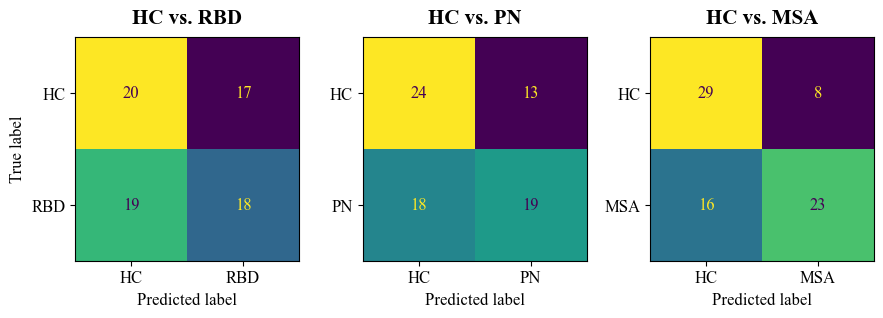

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter

from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

features_monolog_H_sorted = [
    "avg_dur", # 27.67
     "median_dur", # 26.35
    "subharm_sig_ratio", # 16.57
    "longest_dur", # 15.29
     "std_inter_intervals", # 14.74
     "std_dur", # 13.64
    "subharm_per_second", # 8.47
    "mean_inter_intervals", # 8.32 
    "median_inter_intervals", # 7.87
]

df = pd.read_csv("monolog_cont_speech_features.csv")

# force numeric
for col in features_monolog_H_sorted:
    df[col] = pd.to_numeric(df[col], errors="coerce")

diagnoses = ["RBD", "PN", "MSA"]

corr_threshold = 0.8
cv = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
cms = []

for diagnosis in diagnoses:
    print(f"\n--------------- HC vs. {diagnosis} ---------------")

    # binary subset
    df_bin = df[df["group"].isin(["HC", diagnosis])].copy()
    y_all = (df_bin["group"] == diagnosis).astype(int)

    print(f"Initial HC: {(y_all == 0).sum()}")
    print(f"Initial {diagnosis}: {(y_all == 1).sum()}")

    # tracking across folds
    feature_counts = Counter()

    y_true_all = []
    y_pred_all = []
    # y_score_all = []

    fold_accuracies = []
    fold_aucs = []
    fold_selected_features = []

    for fold_idx, (train_idx, test_idx) in enumerate(cv.split(df_bin, y_all), start=1):
        df_train = df_bin.iloc[train_idx].copy()
        df_test = df_bin.iloc[test_idx].copy()

        # ---------- feature selection on TRAIN only ----------
        corr = df_train[features_monolog_H_sorted].corr().abs()

        selected = []
        for f in features_monolog_H_sorted:
            if all(corr.loc[f, s] < corr_threshold for s in selected):
                selected.append(f)

        fold_selected_features.append(selected)
        feature_counts.update(selected)

        # ---------- remove rows with missing/invalid selected features ----------
        df_train = df_train.dropna(subset=selected)
        df_test = df_test.dropna(subset=selected)

        df_train = df_train[np.isfinite(df_train[selected]).all(axis=1)]
        df_test = df_test[np.isfinite(df_test[selected]).all(axis=1)]

        # labels after cleaning
        y_train = (df_train["group"] == diagnosis).astype(int)
        y_test = (df_test["group"] == diagnosis).astype(int)

        X_train = df_train[selected]
        X_test = df_test[selected]

        # skip pathological folds if cleaning removed too much
        if len(np.unique(y_train)) < 2 or len(np.unique(y_test)) < 2:
            print(f"Fold {fold_idx}: skipped (only one class after cleaning)")
            continue

        # ---------- model ----------
        model = make_pipeline(
            StandardScaler(),
            LogisticRegression(penalty="l2", solver="liblinear")
        )

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)
        y_score = model.predict_proba(X_test)[:, 1]

        # ---------- metrics ----------
        acc = accuracy_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_score)

        fold_accuracies.append(acc)
        fold_aucs.append(auc)

        y_true_all.extend(y_test.tolist())
        y_pred_all.extend(y_pred.tolist())
        # y_score_all.extend(y_score.tolist())

        # ---------- coefficients ----------
        # lr = model.named_steps["logisticregression"]
        # for feat, coef in zip(selected, lr.coef_[0]):
        #     coef_values[feat].append(coef)

    # ---------- overall reported performance ----------
    print(f"Mean accuracy: {np.mean(fold_accuracies):.3f} ± {np.std(fold_accuracies):.3f}")
    print(f"Mean AUC: {np.mean(fold_aucs):.3f} ± {np.std(fold_aucs):.3f}")

    # ---------- confusion matrix from out-of-fold predictions ----------
    cm = confusion_matrix(y_true_all, y_pred_all)
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    print(f"Sensitivity {sensitivity:.3f}, specificity {specificity:.3f}")
    cms.append(cm)

    # ConfusionMatrixDisplay.from_predictions(y_true_all, y_pred_all)
    # plt.title(f"Confusion Matrix HC vs. {diagnosis}")
    # plt.show()

    print("\nClassification report:")
    print(classification_report(y_true_all, y_pred_all, digits=3))

    # ---------- general features to use ----------
    print("\nFeature selection stability across folds:")
    stable_features = []

    for feat in features_monolog_H_sorted:
        count = feature_counts[feat]
        if count > 0:
            print(f"{feat}: selected in {count}/{cv.get_n_splits()} folds")
        if count >= 3:   # threshold: selected in at least 3 of 5 folds
            stable_features.append(feat)

    print("\nGeneral feature set to use:")
    print(f"{len(stable_features)} stable features out of {len(features_monolog_H_sorted)}")
    print(stable_features)

fig, axes = plt.subplots(1, 3, figsize=(9, 6))

for i, diagnosis in enumerate(diagnoses):
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cms[i],
        display_labels=["HC", diagnosis]
    )
    disp.plot(ax=axes[i], colorbar=False)
    axes[i].set_title(f"HC vs. {diagnosis}", fontweight="bold", pad=10)
    axes[i].set_xlabel("Predicted label", fontsize=12)
    if i == 0:
        axes[i].set_ylabel("True label", fontsize=12)
    else:
        axes[i].set_ylabel("")  # remove from others

plt.tight_layout()
plt.savefig("classifier_results_monolog.png", dpi=300)
plt.show()


--------------- HC vs. RBD ---------------
Initial HC: 84
Initial RBD: 84
Mean accuracy: 0.668 ± 0.109
Mean AUC: 0.655 ± 0.115
Sensitivity 0.486, specificity 0.809

Classification report:
              precision    recall  f1-score   support

           0      0.667     0.809     0.731        47
           1      0.667     0.486     0.562        37

    accuracy                          0.667        84
   macro avg      0.667     0.647     0.647        84
weighted avg      0.667     0.667     0.657        84


Feature selection stability across folds:
subharm_num: selected in 5/5 folds
longest_dur: selected in 5/5 folds
median_dur: selected in 5/5 folds
median_inter_intervals: selected in 5/5 folds
pct_subharm_num_2nd_half: selected in 5/5 folds
CV_dur: selected in 5/5 folds
COV_inter_intervals: selected in 5/5 folds
first_occur: selected in 5/5 folds

General feature set to use:
8 stable features out of 13
['subharm_num', 'longest_dur', 'median_dur', 'median_inter_intervals', 'pct_su

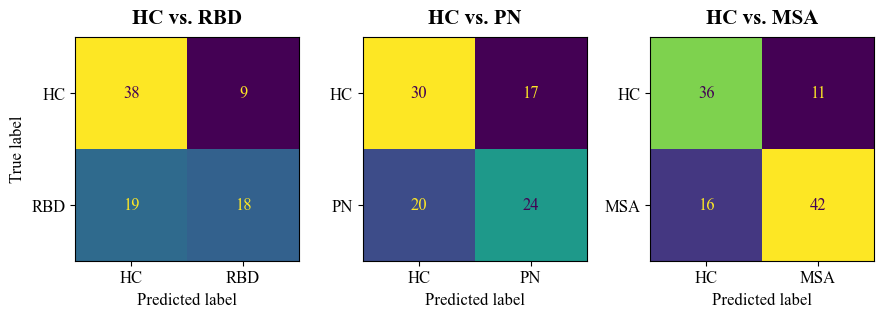

In [35]:
features_zahradnik_H_sorted = [
    "subharm_num", # 24.20
    "longest_dur", # 23.13
    "avg_dur", # 21.28
    "subharm_sig_ratio", # 20.99
    "std_dur", # 20.63
    "subharm_per_second", # 19.44
    "median_dur", # 17.63
    "median_inter_intervals", # 11.90
    "pct_subharm_num_2nd_half", # 9.95
    "CV_dur", # 9.56
    "COV_inter_intervals", # 9.00
    "first_occur", # 8.55
    "pct_subharm_dur_2nd_half", # 8.26
]

df = pd.read_csv("zahradnik_cont_speech_features.csv")

# force numeric
for col in features_zahradnik_H_sorted:
    df[col] = pd.to_numeric(df[col], errors="coerce")

diagnoses = ["RBD", "PN", "MSA"]

corr_threshold = 0.8
cv = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
cms = []

for diagnosis in diagnoses:
    print(f"\n--------------- HC vs. {diagnosis} ---------------")

    # binary subset
    df_bin = df[df["group"].isin(["HC", diagnosis])].copy()
    y_all = (df_bin["group"] == diagnosis).astype(int)

    print(f"Initial HC: {(y_all == 0).sum()}")
    print(f"Initial {diagnosis}: {(y_all == 1).sum()}")

    # tracking across folds
    feature_counts = Counter()

    y_true_all = []
    y_pred_all = []
    # y_score_all = []

    fold_accuracies = []
    fold_aucs = []
    fold_selected_features = []

    for fold_idx, (train_idx, test_idx) in enumerate(cv.split(df_bin, y_all), start=1):
        df_train = df_bin.iloc[train_idx].copy()
        df_test = df_bin.iloc[test_idx].copy()

        # ---------- feature selection on TRAIN only ----------
        corr = df_train[features_zahradnik_H_sorted].corr().abs()

        selected = []
        for f in features_zahradnik_H_sorted:
            if all(corr.loc[f, s] < corr_threshold for s in selected):
                selected.append(f)

        fold_selected_features.append(selected)
        feature_counts.update(selected)

        # ---------- remove rows with missing/invalid selected features ----------
        df_train = df_train.dropna(subset=selected)
        df_test = df_test.dropna(subset=selected)

        df_train = df_train[np.isfinite(df_train[selected]).all(axis=1)]
        df_test = df_test[np.isfinite(df_test[selected]).all(axis=1)]

        # labels after cleaning
        y_train = (df_train["group"] == diagnosis).astype(int)
        y_test = (df_test["group"] == diagnosis).astype(int)

        X_train = df_train[selected]
        X_test = df_test[selected]

        # skip pathological folds if cleaning removed too much
        if len(np.unique(y_train)) < 2 or len(np.unique(y_test)) < 2:
            print(f"Fold {fold_idx}: skipped (only one class after cleaning)")
            continue

        # ---------- model ----------
        model = make_pipeline(
            StandardScaler(),
            LogisticRegression(penalty="l2", solver="liblinear")
        )

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)
        y_score = model.predict_proba(X_test)[:, 1]

        # ---------- metrics ----------
        acc = accuracy_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_score)

        fold_accuracies.append(acc)
        fold_aucs.append(auc)

        y_true_all.extend(y_test.tolist())
        y_pred_all.extend(y_pred.tolist())
        # y_score_all.extend(y_score.tolist())

        # ---------- coefficients ----------
        # lr = model.named_steps["logisticregression"]
        # for feat, coef in zip(selected, lr.coef_[0]):
        #     coef_values[feat].append(coef)

    # ---------- overall reported performance ----------
    print(f"Mean accuracy: {np.mean(fold_accuracies):.3f} ± {np.std(fold_accuracies):.3f}")
    print(f"Mean AUC: {np.mean(fold_aucs):.3f} ± {np.std(fold_aucs):.3f}")

    # ---------- confusion matrix from out-of-fold predictions ----------
    cm = confusion_matrix(y_true_all, y_pred_all)
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    print(f"Sensitivity {sensitivity:.3f}, specificity {specificity:.3f}")
    cms.append(cm)

    # ConfusionMatrixDisplay.from_predictions(y_true_all, y_pred_all)
    # plt.title(f"Confusion Matrix HC vs. {diagnosis}")
    # plt.show()

    print("\nClassification report:")
    print(classification_report(y_true_all, y_pred_all, digits=3))

    # ---------- general features to use ----------
    print("\nFeature selection stability across folds:")
    stable_features = []

    for feat in features_zahradnik_H_sorted:
        count = feature_counts[feat]
        if count > 0:
            print(f"{feat}: selected in {count}/{cv.get_n_splits()} folds")
        if count >= 3:   # threshold: selected in at least 3 of 5 folds
            stable_features.append(feat)

    print("\nGeneral feature set to use:")
    print(f"{len(stable_features)} stable features out of {len(features_zahradnik_H_sorted)}")
    print(stable_features)

fig, axes = plt.subplots(1, 3, figsize=(9, 6))

for i, diagnosis in enumerate(diagnoses):
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cms[i],
        display_labels=["HC", diagnosis]
    )
    disp.plot(ax=axes[i], colorbar=False)
    axes[i].set_title(f"HC vs. {diagnosis}", fontweight="bold", pad=10)
    axes[i].set_xlabel("Predicted label", fontsize=12)
    if i == 0:
        axes[i].set_ylabel("True label", fontsize=12)
    else:
        axes[i].set_ylabel("")  # remove from others

plt.tight_layout()
plt.savefig("classifier_results_zahradnik.png", dpi=300)
plt.show()


--------------- HC vs. RBD ---------------
Initial HC: 126
Initial RBD: 125
Mean accuracy: 0.578 ± 0.096
Mean AUC: 0.616 ± 0.092
Sensitivity 0.405, specificity 0.714

Classification report:
              precision    recall  f1-score   support

           0      0.577     0.714     0.638        84
           1      0.556     0.405     0.469        74

    accuracy                          0.570       158
   macro avg      0.566     0.560     0.554       158
weighted avg      0.567     0.570     0.559       158


Feature selection stability across folds:
avg_dur: selected in 5/5 folds
median_dur: selected in 1/5 folds
subharm_sig_ratio: selected in 5/5 folds
longest_dur: selected in 2/5 folds
subharm_per_second: selected in 4/5 folds
subharm_num: selected in 5/5 folds
std_inter_intervals: selected in 5/5 folds
median_inter_intervals: selected in 5/5 folds
pct_subharm_num_2nd_half: selected in 5/5 folds
COV_inter_intervals: selected in 5/5 folds

General feature set to use:
8 stable fea

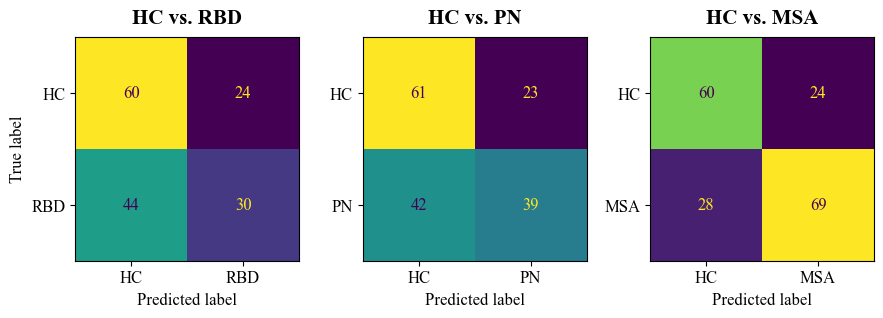

In [36]:


features_overall_H_sorted = [
    "avg_dur", # 38.51
    "median_dur", # 37.39
    "subharm_sig_ratio", # 34.43
    "longest_dur", # 31.57
    "std_dur", # 26.60
    "subharm_per_second", # 24.81
    "subharm_num", # 18.98
    "std_inter_intervals",  # 15.02
    "median_inter_intervals", # 13.64
    "pct_subharm_num_2nd_half", # 10.85
    "COV_inter_intervals", # 8.79
    "mean_inter_intervals" # 8.10 
]

df = pd.read_csv("overall_cont_speech_features.csv")

# force numeric
for col in features_overall_H_sorted:
    df[col] = pd.to_numeric(df[col], errors="coerce")

diagnoses = ["RBD", "PN", "MSA"]

corr_threshold = 0.8
cv = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
cms = []

for diagnosis in diagnoses:
    print(f"\n--------------- HC vs. {diagnosis} ---------------")

    # binary subset
    df_bin = df[df["group"].isin(["HC", diagnosis])].copy()
    y_all = (df_bin["group"] == diagnosis).astype(int)

    print(f"Initial HC: {(y_all == 0).sum()}")
    print(f"Initial {diagnosis}: {(y_all == 1).sum()}")

    # tracking across folds
    feature_counts = Counter()

    y_true_all = []
    y_pred_all = []
    # y_score_all = []

    fold_accuracies = []
    fold_aucs = []
    fold_selected_features = []

    for fold_idx, (train_idx, test_idx) in enumerate(cv.split(df_bin, y_all), start=1):
        df_train = df_bin.iloc[train_idx].copy()
        df_test = df_bin.iloc[test_idx].copy()

        # ---------- feature selection on TRAIN only ----------
        corr = df_train[features_overall_H_sorted].corr().abs()

        selected = []
        for f in features_overall_H_sorted:
            if all(corr.loc[f, s] < corr_threshold for s in selected):
                selected.append(f)

        fold_selected_features.append(selected)
        feature_counts.update(selected)

        # ---------- remove rows with missing/invalid selected features ----------
        df_train = df_train.dropna(subset=selected)
        df_test = df_test.dropna(subset=selected)

        df_train = df_train[np.isfinite(df_train[selected]).all(axis=1)]
        df_test = df_test[np.isfinite(df_test[selected]).all(axis=1)]

        # labels after cleaning
        y_train = (df_train["group"] == diagnosis).astype(int)
        y_test = (df_test["group"] == diagnosis).astype(int)

        X_train = df_train[selected]
        X_test = df_test[selected]

        # skip pathological folds if cleaning removed too much
        if len(np.unique(y_train)) < 2 or len(np.unique(y_test)) < 2:
            print(f"Fold {fold_idx}: skipped (only one class after cleaning)")
            continue

        # ---------- model ----------
        model = make_pipeline(
            StandardScaler(),
            LogisticRegression(penalty="l2", solver="liblinear")
        )

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)
        y_score = model.predict_proba(X_test)[:, 1]

        # ---------- metrics ----------
        acc = accuracy_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_score)

        fold_accuracies.append(acc)
        fold_aucs.append(auc)

        y_true_all.extend(y_test.tolist())
        y_pred_all.extend(y_pred.tolist())
        # y_score_all.extend(y_score.tolist())

        # ---------- coefficients ----------
        # lr = model.named_steps["logisticregression"]
        # for feat, coef in zip(selected, lr.coef_[0]):
        #     coef_values[feat].append(coef)

    # ---------- overall reported performance ----------
    print(f"Mean accuracy: {np.mean(fold_accuracies):.3f} ± {np.std(fold_accuracies):.3f}")
    print(f"Mean AUC: {np.mean(fold_aucs):.3f} ± {np.std(fold_aucs):.3f}")

    # ---------- confusion matrix from out-of-fold predictions ----------
    cm = confusion_matrix(y_true_all, y_pred_all)
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    print(f"Sensitivity {sensitivity:.3f}, specificity {specificity:.3f}")
    cms.append(cm)

    # ConfusionMatrixDisplay.from_predictions(y_true_all, y_pred_all)
    # plt.title(f"Confusion Matrix HC vs. {diagnosis}")
    # plt.show()

    print("\nClassification report:")
    print(classification_report(y_true_all, y_pred_all, digits=3))

    # ---------- general features to use ----------
    print("\nFeature selection stability across folds:")
    stable_features = []

    for feat in features_overall_H_sorted:
        count = feature_counts[feat]
        if count > 0:
            print(f"{feat}: selected in {count}/{cv.get_n_splits()} folds")
        if count >= 3:   # threshold: selected in at least 3 of 5 folds
            stable_features.append(feat)

    print("\nGeneral feature set to use:")
    print(f"{len(stable_features)} stable features out of {len(features_overall_H_sorted)}")
    print(stable_features)

fig, axes = plt.subplots(1, 3, figsize=(9, 6))

for i, diagnosis in enumerate(diagnoses):
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cms[i],
        display_labels=["HC", diagnosis]
    )
    disp.plot(ax=axes[i], colorbar=False)
    axes[i].set_title(f"HC vs. {diagnosis}", fontweight="bold", pad=10)
    axes[i].set_xlabel("Predicted label", fontsize=12)
    if i == 0:
        axes[i].set_ylabel("True label", fontsize=12)
    else:
        axes[i].set_ylabel("")  # remove from others

plt.tight_layout()
plt.savefig("classifier_results_overall.png", dpi=300)
plt.show()

    # ---------- features driving reported performance ----------
    # print("\nFeature coefficient summary (only for folds where selected):")
    # coef_summary = []

    # for feat in features_overall_H_sorted:
    #     vals = coef_values[feat]
    #     if len(vals) > 0:
    #         mean_coef = np.mean(vals)
    #         mean_abs_coef = np.mean(np.abs(vals))
    #         coef_summary.append((feat, len(vals), mean_coef, mean_abs_coef))

    # coef_summary = sorted(coef_summary, key=lambda x: x[3], reverse=True)

    # coef_df = pd.DataFrame(
    #     coef_summary,
    #     columns=["feature", "selected_in_folds", "mean_coef", "mean_abs_coef"]
    # )

    # print(coef_df.to_string(index=False))